# Causal Inference and Uplift Modeling: End-to-End Tutorial

In marketplace systems, discounting should answer a **causal** question:

- What *change* in conversion happens because we gave a discount?

This differs from standard predictive ML, which asks:

- Who is likely to convert?

The **Fundamental Problem of Causal Inference** is that for each rider, we only observe one reality:

- If treated: we observe $Y(1)$
- If not treated: we observe $Y(0)$
- We never observe both for the same rider simultaneously

So causal ML aims to estimate treatment effect, often as a conditional quantity:

- $\tau(x) = \mathbb{E}[Y(1)-Y(0) \mid X=x]$ (CATE)


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import auc

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'caudyn').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from caudyn.environment import UberMarketplaceEnvironment
from caudyn.r_learner import RLearner

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


## Step 1: The Environment and the Confounding Illusion

We begin with **biased observational data** generated by a legacy policy.

The policy tends to give larger discounts to high-frequency riders. That creates **selection bias**:

- Treated riders are systematically different from untreated riders
- A naive average difference mixes rider quality with treatment impact

We will compare:

1. **Naive ATE**: conversion(20%) - conversion(0%) from raw logs
2. **True ATE**: oracle causal effect from the simulator's hidden physics


In [2]:
env = UberMarketplaceEnvironment(seed=42)
df_hist = env.generate_biased_historical_data(num_samples=50_000)

features = ['recency', 'frequency', 'weather_active', 'surge_multiplier']

mean_conv_0 = df_hist.loc[df_hist['treatment'] == 0, 'converted'].mean()
mean_conv_20 = df_hist.loc[df_hist['treatment'] == 2, 'converted'].mean()
naive_ate = mean_conv_20 - mean_conv_0

def true_lift_20pct(row):
    context = {
        'recency': row['recency'],
        'frequency': row['frequency'],
        'weather_active': row['weather_active'],
        'surge_multiplier': row['surge_multiplier'],
    }
    return env._calculate_true_conversion(context, 2) - env._calculate_true_conversion(context, 0)

def cal_true_conversion_20pct(row):
    context = {
        'recency': row['recency'],
        'frequency': row['frequency'],
        'weather_active': row['weather_active'],
        'surge_multiplier': row['surge_multiplier'],
    }
    return env._calculate_true_conversion(context, 2)

def cal_true_conversion_0pct(row):
    context = {
        'recency': row['recency'],
        'frequency': row['frequency'],
        'weather_active': row['weather_active'],
        'surge_multiplier': row['surge_multiplier'],
    }
    return env._calculate_true_conversion(context, 0)

df_hist['true_conversion_20pct'] = df_hist.apply(cal_true_conversion_20pct, axis=1)
true_conversion_20pct = df_hist['true_conversion_20pct'].mean()
df_hist['true_conversion_0pct'] = df_hist.apply(cal_true_conversion_0pct, axis=1)
true_conversion_0pct = df_hist['true_conversion_0pct'].mean()
df_hist['true_cate_20pct'] = df_hist['true_conversion_20pct'] - df_hist['true_conversion_0pct']
true_ate = df_hist['true_cate_20pct'].mean()

summary_step1 = pd.DataFrame({
    'Metric': [
        'Naive conversion @ 20%',
        'Naive conversion @ 0%',
        'Naive ATE (20% - 0%)',
        'True conversion @ 20%',
        'True conversion @ 0%',
        'True ATE (physics oracle)',
        'Bias (Naive - True)',
        
    ],
    'Value': [mean_conv_20, mean_conv_0, naive_ate, true_conversion_20pct, true_conversion_0pct, true_ate, naive_ate - true_ate]
})

print(f'Rows generated: {len(df_hist):,}')
display(summary_step1.style.format({'Value': '{:.2%}'}))

policy_diagnosis = df_hist.groupby('treatment')['frequency'].mean().rename('avg_frequency').to_frame()
print('Average monthly frequency by treatment arm (legacy policy):')
display(policy_diagnosis)


Rows generated: 50,000


,Metric,Value
0,Naive conversion @ 20%,59.17%
1,Naive conversion @ 0%,13.20%
2,Naive ATE (20% - 0%),45.97%
3,True conversion @ 20%,41.15%
4,True conversion @ 0%,35.36%
5,True ATE (physics oracle),5.79%
6,Bias (Naive - True),40.18%


Average monthly frequency by treatment arm (legacy policy):


,avg_frequency
treatment,
0,4.683069
1,10.453955
2,16.323842


### Why Naive ATE Is Wrong

Naive ATE assumes treated and control groups are exchangeable. They are not.

Because the legacy policy targets frequent (already likely-to-convert) riders with larger discounts, the treated group carries built-in baseline advantage.

So the naive estimate over-credits discount for conversions that would have happened anyway. This is confounding in action.


## Step 2: Causal Estimation with the R-Learner

The R-Learner is a **Double Machine Learning** method:

1. Learn baseline outcome model: $\mu(x)=\mathbb{E}[Y\mid X=x]$
2. Learn treatment model: $e(x)=\mathbb{E}[T\mid X=x]$
3. Residualize both outcome and treatment, then fit treatment effect model on residual signal

This residualization helps isolate causal signal from nuisance structure.


In [3]:
X_train = df_hist[features]
T_train = df_hist['discount_value']
Y_train = df_hist['converted']

r_learner = RLearner(random_state=42, cv=5, epsilon=1e-6)
r_learner.fit(X_train, T_train, Y_train)

# RLearner predicts effect per 1.0 treatment unit; scale to 0.2 (20% discount).
df_hist['pred_cate_per_unit'] = r_learner.predict_cate(X_train)
df_hist['pred_lift_20pct'] = 0.2 * df_hist['pred_cate_per_unit']

print('R-Learner trained on biased observational data.')
print('Average predicted 20% lift:', f"{df_hist['pred_lift_20pct'].mean():.2%}")
print('Average true 20% lift:     ', f"{df_hist['true_cate_20pct'].mean():.2%}")


R-Learner trained on biased observational data.
Average predicted 20% lift: 6.16%
Average true 20% lift:      5.79%


## Step 3: Randomized Holdout (Ground-Truth Sandbox)

We should not validate uplift quality on confounded training logs.

Instead, create a fresh **RCT-like** test set where treatment assignment is random (0% vs 20%).

Randomization breaks the correlation between rider profile and treatment, so treated-control differences within a segment are causally interpretable.


In [4]:
env_rct = UberMarketplaceEnvironment(seed=999)
rng = np.random.default_rng(999)

rct_rows = []
for _ in range(20_000):
    context = env_rct.reset()
    action = int(rng.choice([0, 2]))
    _, reward, true_prob = env_rct.step(action)

    row = context.copy()
    row['treatment'] = action
    row['discount_value'] = env_rct.discount_levels[action]
    row['converted'] = reward
    row['true_prob_observed'] = true_prob
    rct_rows.append(row)

df_rct = pd.DataFrame(rct_rows)

X_rct = df_rct[features]
df_rct['pred_cate_per_unit'] = r_learner.predict_cate(X_rct)
df_rct['pred_lift_20pct'] = 0.2 * df_rct['pred_cate_per_unit']

def true_lift_20pct_rct(row):
    context = {
        'recency': row['recency'],
        'frequency': row['frequency'],
        'weather_active': row['weather_active'],
        'surge_multiplier': row['surge_multiplier'],
    }
    return env_rct._calculate_true_conversion(context, 2) - env_rct._calculate_true_conversion(context, 0)

df_rct['true_cate_20pct'] = df_rct.apply(true_lift_20pct_rct, axis=1)

print(f'RCT rows generated: {len(df_rct):,}')
print('Treatment share (near 50/50 expected):')
display(df_rct['treatment'].value_counts(normalize=True).sort_index().rename('share'))
print('Average predicted 20% lift on RCT data:', f"{df_rct['pred_lift_20pct'].mean():.2%}")
print('Average true 20% lift on RCT data:     ', f"{df_rct['true_cate_20pct'].mean():.2%}")

RCT rows generated: 20,000
Treatment share (near 50/50 expected):


treatment
0    0.4994
2    0.5006
Name: share, dtype: float64

Average predicted 20% lift on RCT data: 5.85%
Average true 20% lift on RCT data:      5.68%


## Step 4: Validation Part 1 - Decile Binning

Individual counterfactuals are missing, but group-level validation is feasible:

1. Rank users by predicted uplift
2. Split into deciles
3. In each decile, compute actual lift from randomized treated vs control outcomes

A strong uplift model should show higher actual lift in top deciles and lower lift in bottom deciles.


,Decile,Predicted_Lift,Actual_Lift,n
0,1,33.12%,10.66%,2000
1,2,22.11%,15.54%,2000
2,3,16.37%,6.49%,2000
3,4,11.99%,6.17%,2000
4,5,7.84%,7.45%,2000
5,6,3.75%,1.40%,2000
6,7,-0.37%,4.44%,2000
7,8,-4.77%,4.68%,2000
8,9,-10.22%,3.98%,2000
9,10,-21.35%,3.57%,2000


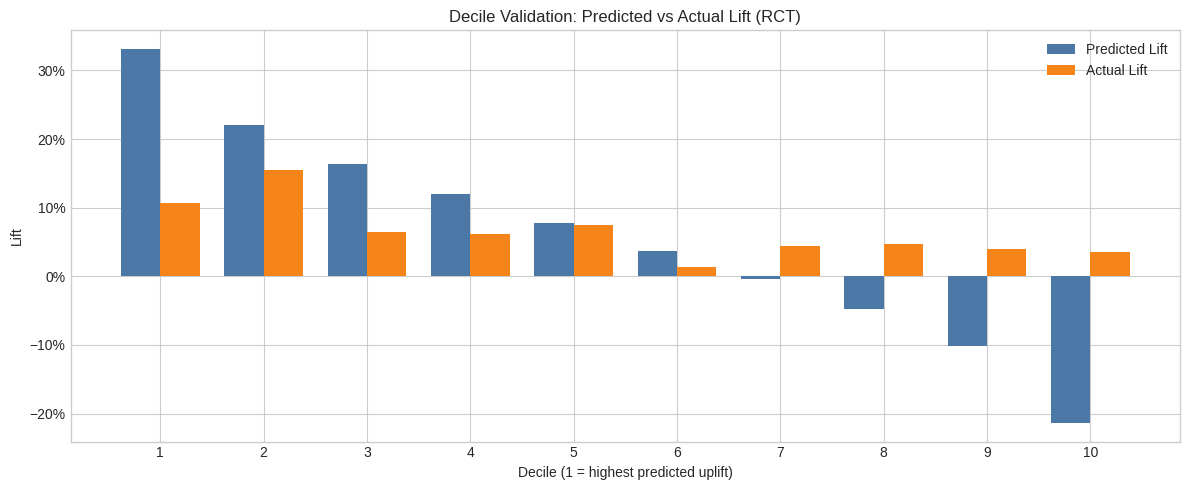

In [5]:
df_ranked = df_rct.sort_values('pred_lift_20pct', ascending=False).reset_index(drop=True)
df_ranked['decile'] = pd.qcut(df_ranked.index, q=10, labels=np.arange(1, 11))

decile_rows = []
for d in range(1, 11):
    ddf = df_ranked[df_ranked['decile'] == d]

    conv_treated = ddf.loc[ddf['treatment'] == 2, 'converted'].mean()
    conv_control = ddf.loc[ddf['treatment'] == 0, 'converted'].mean()

    decile_rows.append({
        'Decile': d,
        'Predicted_Lift': ddf['pred_lift_20pct'].mean(),
        'Actual_Lift': conv_treated - conv_control,
        'n': len(ddf)
    })

deciles_df = pd.DataFrame(decile_rows)
display(deciles_df.style.format({'Predicted_Lift': '{:.2%}', 'Actual_Lift': '{:.2%}'}))

x = np.arange(len(deciles_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, deciles_df['Predicted_Lift'], width, label='Predicted Lift', color='#4C78A8')
ax.bar(x + width / 2, deciles_df['Actual_Lift'], width, label='Actual Lift', color='#F58518')

ax.set_title('Decile Validation: Predicted vs Actual Lift (RCT)')
ax.set_xlabel('Decile (1 = highest predicted uplift)')
ax.set_ylabel('Lift')
ax.set_xticks(x)
ax.set_xticklabels(deciles_df['Decile'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

plt.tight_layout()
plt.show()


## Step 5: Validation Part 2 - Qini Curve and Coefficient

Decile analysis is local. The Qini curve gives a **global business value** view:

- As we target larger fractions of users, how much cumulative incremental conversion do we gain?

We compare:

1. **Model curve** (sorted by predicted uplift)
2. **Random baseline** (no ranking skill)
3. **Perfect curve** (sorted by true uplift; simulation oracle)

Normalized Qini score:

$$
\text{Qini}_{\text{norm}} = \frac{A_{\text{model}} - A_{\text{random}}}{A_{\text{perfect}} - A_{\text{random}}}
$$

The closer to 1, the closer we are to perfect uplift ranking.


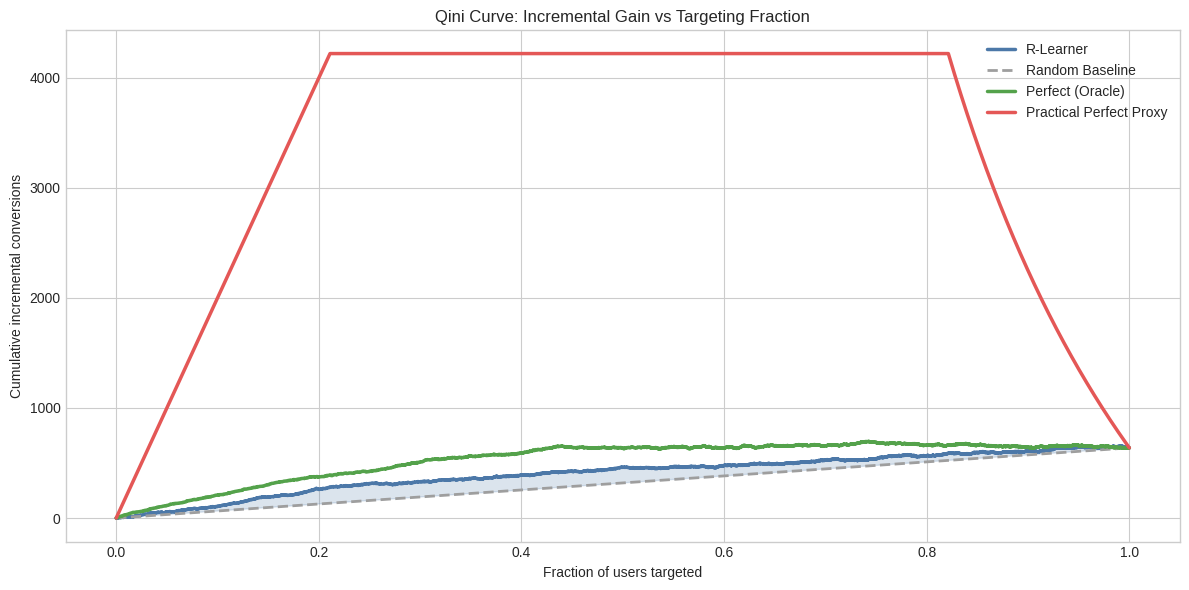

AUC(model):   404.53
AUC(random):  318.71
AUC(perfect): 531.23
AUC(practical perfect): 3,407.17

Normalized Qini Score (with true CATE): 0.404

Normalized Qini Score (with practical perfect proxy): 0.028


In [8]:
def calculate_qini_curve(df):
    w = (df['treatment'] == 2).astype(int).to_numpy()
    y = df['converted'].to_numpy()

    cum_treated = np.cumsum(w)
    cum_control = np.cumsum(1 - w)
    cum_y_treated = np.cumsum(y * w)
    cum_y_control = np.cumsum(y * (1 - w))

    eps = 1e-10
    incremental_gain = cum_y_treated - cum_y_control * (cum_treated / (cum_control + eps))
    return np.insert(incremental_gain, 0, 0.0)

qini_model = calculate_qini_curve(df_ranked)

df_perfect = df_rct.sort_values('true_cate_20pct', ascending=False).reset_index(drop=True)
qini_perfect = calculate_qini_curve(df_perfect)

x_axis = np.arange(len(df_ranked) + 1) / len(df_ranked)
qini_random = x_axis * qini_model[-1]


def get_practical_perfect_predictions(df, treatment_arm=2):
    """
    Generates the optimistic proxy for True CATE.
    
    Parameters:
    df: The validation dataframe
    treatment_arm: The specific treatment integer we are evaluating (e.g., 2 for the 20% discount)
    """
    perfect_predictions = np.zeros(len(df))
    
    # 1. Put Treated Converters (for our specific discount) at the very top
    mask_treated_success = (df['treatment'] == treatment_arm) & (df['converted'] == 1)
    perfect_predictions[mask_treated_success] = 1.0  # Dummy weight for sorting
    
    # 2. Put Control Converters at the very bottom
    mask_control_success = (df['treatment'] == 0) & (df['converted'] == 1)
    perfect_predictions[mask_control_success] = -1.0 # Dummy weight for sorting
    
    # Everyone else (Outcome = 0 or different treatments) stays at 0.0 in the middle
    
    return perfect_predictions

# --- How to apply it in your validation pipeline ---

# We only want to evaluate the 20% discount (Treatment 2) against Control (Treatment 0)
df_eval = df_rct[df_rct['treatment'].isin([0, 2])].copy()

# Generate the dummy scores
df_eval['practical_perfect_cate'] = get_practical_perfect_predictions(df_eval, treatment_arm=2)

# Sort the dataframe using the dummy scores (This is the only thing the 1.0 and -1.0 do!)
df_practical_perfect_ranked = df_eval.sort_values(by='practical_perfect_cate', ascending=False).reset_index(drop=True)

# Now pass the properly sorted dataframe to your calculate_qini function
qini_practical_perfect_curve = calculate_qini_curve(df_practical_perfect_ranked)


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_axis, qini_model, label='R-Learner', color='#4C78A8', linewidth=2.5)
ax.plot(x_axis, qini_random, label='Random Baseline', color='#9E9E9E', linestyle='--', linewidth=2)
ax.plot(x_axis, qini_perfect, label='Perfect (Oracle)', color='#54A24B', linewidth=2.5)
ax.plot(x_axis, qini_practical_perfect_curve, label='Practical Perfect Proxy', color='#E45756', linewidth=2.5)

ax.fill_between(
    x_axis,
    qini_random,
    qini_model,
    where=(qini_model >= qini_random),
    color='#4C78A8',
    alpha=0.2,
    interpolate=True
)

ax.set_title('Qini Curve: Incremental Gain vs Targeting Fraction')
ax.set_xlabel('Fraction of users targeted')
ax.set_ylabel('Cumulative incremental conversions')
ax.legend()

plt.tight_layout()
plt.show()

area_model = auc(x_axis, qini_model)
area_random = auc(x_axis, qini_random)
area_perfect = auc(x_axis, qini_perfect)
area_practical_perfect = auc(x_axis, qini_practical_perfect_curve)
denom = area_perfect - area_random
qini_score = np.nan if abs(denom) < 1e-12 else (area_model - area_random) / denom

denom_practical = area_practical_perfect - area_random
qini_practical = np.nan if abs(denom_practical) < 1e-12 else (area_model - area_random) / denom_practical

print(f'AUC(model):   {area_model:,.2f}')
print(f'AUC(random):  {area_random:,.2f}')
print(f'AUC(perfect): {area_perfect:,.2f}')
print(f'AUC(practical perfect): {area_practical_perfect:,.2f}')
print(f'\nNormalized Qini Score (with true CATE): {qini_score:.3f}')
print(f'\nNormalized Qini Score (with practical perfect proxy): {qini_practical:.3f}')

## Key Takeaways

1. Observational logs can produce large causal illusions under confounding.
2. R-Learner (Double ML) helps recover heterogeneous treatment signal.
3. Honest uplift validation requires randomized holdout data.
4. Decile lift and Qini together provide segment-level and global business-value diagnostics.

In production, monitor both decile ordering and Qini drift over time as market behavior changes.
